<p>
<h1><b><center></center></b></h1>
</p>
<h1><b><center>Space Flight Dynamics</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Assigment 1</center></b><h2>
<h3><b><center>Long-Range Ballistic Trajectory</center></b><h3>
<h5><center><b>Asignada</b>: 10 de marzo de 2025</center><h5>
<h5><center><b>Entrega</b>: 31 de marzo de 2025</center><h5>

<hr/>
<b>Name</b>: Naireth Farak Román
<br/>
<b>National ID</b>: 1102812285
<br/>
<b>Last update</b>: March 30, 2025 18:28
<hr/>

## Statement

The equations of motion for a vehicle moving over the surface of an approximately spherical Earth are (Example 13.3, page 714, from [Orbital Mechanics for Engineering
Students](https://drive.google.com/file/d/1RxppVFvxwwFMDd7GBd-z5Bfj8wQZt5JT/view?usp=classroom_web&authuser=0)):

\[
\begin{aligned}
& \frac{\mathrm{d} v}{\mathrm{~d} t}=\frac{T}{m}-\frac{D}{m}-g \sin \gamma \\
& \frac{\mathrm{d} \gamma}{\mathrm{~d} t}=-\frac{1}{v}\left(g-\frac{v^2}{R_E+h}\right) \cos \gamma \\
& \frac{\mathrm{d} h}{\mathrm{~d} t}=v \sin \gamma \\
& \frac{\mathrm{d} x}{\mathrm{~d} t}=\frac{R_E}{R_E+h} v \cos \gamma
\end{aligned}
\]

where:

- $x$ is the horizontal distance traveled by the vehicle (an arc over the Earth's surface; see Figure 13.1, page 706 of [Orbital Mechanics for Engineering
Students](https://drive.google.com/file/d/1RxppVFvxwwFMDd7GBd-z5Bfj8wQZt5JT/view?usp=classroom_web&authuser=0))
- $h$ is the height above the spherical surface of the Earth.
- $R_E = 6378$ km is the Earth's mean radius.
- $g = g_0/(1+h/R_E)^2$ is the gravitational acceleration at height $h$, with $g_0 = 9.81$ m/s$^2$ the sea-level acceleration (*datum*).
- $\gamma$ is the *flight path angle*.
- $T$ is the *thrust* force.
- $D$ is the atmospheric *drag*.

Assuming that a rocket reaches its maximum speed after exhausting its fuel (*burnout* or engine shutdown) at $h_0 = 5$ km, when the flight path angle is $\gamma_0 = 45^\circ$ and the speed is $v_0=2$ km/s (Mach 5.9), solve the equations of motion to calculate the rocket's trajectory *until it impacts the surface again*. Calculate the flight time and the distance to the *burnout* point. For simplicity, assume that atmospheric *drag* can be neglected during the flight after *burnout*.

> **NOTE**: If you are interested in the theory used to derive these equations, read Section 13.2 of the reference text.

**Expected results**:
- Plot of the trajectory including a simplified representation of the Earth's surface (circle or sphere).
- Total flight time and distance along the Earth's surface at which the vehicle impacts.

## Solution

First, the libraries needed to develop the code are imported:

In [1]:
from scipy import constants
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
from scipy.integrate import solve_ivp
from plotly.subplots import make_subplots

### Functions

The variables used in the problem are defined:

In [2]:
g0 = 9.81   # Gravity in (m/s^2)
RE = 6378e3 # Earth's radius in (m)

There is a change in the
*acceleration function or velocity derivative*:

$$
\begin{equation}
  \frac{\mathrm{d} v}{\mathrm{~d} t}=\frac{T}{m}-\frac{D}{m}-g \sin \gamma
\end{equation}
$$

The effect of drag ($D$) is neglected because, at the altitude stated in the problem, the density is low (the parameter on which atmospheric drag depends), and because this is a post-burnout problem, the thrust ($T$) is understood to be zero.

Therefore, the function becomes:

$$
\frac{\mathrm{d} v}{\mathrm{~d} t}=-g \sin \gamma
$$

The other functions remain unchanged.

The functions are defined in the routine:

In [3]:
def movimiento(t, ys):
  g = (g0)/(1+(ys[1]/RE))**2

  f0 = (RE/(RE+ys[1]))*(ys[2])*(np.cos(ys[3]))
  f1 = ys[2]*np.sin(ys[3])
  f2 = (-g)*(np.sin(ys[3]))
  f3 = (-1/ys[2])*(g-((ys[2]**2)/(RE+ys[1])))*(np.cos(ys[3]))

  return [f0, f1, f2, f3]

The initial conditions proposed when the rocket reaches its maximum speed are defined:

In [4]:
x0 = 0                  # Position in x
h0 = 5e3                # Height in (m)
v0 = 2e3                # Speed in (m/s)
gamma0 = 45*(np.pi/180) # Flight path angle in degrees (°)

# Initial conditions
y_0 = [x0, h0, v0, gamma0]
T = 2000
ts = np.linspace(0, T, 1000)

Condition for the function to stop when the rocket touches the Earth:

In [5]:
def golpea_tierra(t, ys):
  condicion = ys[1]
  return condicion

golpea_tierra.terminal = True

The solution is obtained:

In [6]:
solucion = solve_ivp(movimiento, [0, T], y_0, t_eval = ts, events=golpea_tierra)
solucion

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  2.002e+00 ...  3.043e+02  3.063e+02]
        y: [[ 0.000e+00  2.828e+03 ...  4.211e+05  4.239e+05]
            [ 5.000e+03  7.812e+03 ...  4.593e+03  1.743e+03]
            [ 2.000e+03  1.986e+03 ...  2.000e+03  2.014e+03]
            [ 7.854e-01  7.789e-01 ... -7.857e-01 -7.921e-01]]
      sol: None
 t_events: [array([ 3.075e+02])]
 y_events: [array([[ 4.256e+05, -2.910e-11,  2.022e+03, -7.960e-01]])]
     nfev: 68
     njev: 0
      nlu: 0

The solution is extracted correctly:

In [7]:
cohete = solucion.y[0:4].T
n = len (cohete)

The dataframe is created with the previously obtained data:

In [8]:
df1 = pd.DataFrame(cohete, columns=['x','h','velocidad', 'gamma'])
df1 =df1.assign(tiempo = ts[:n])
df1

,x,h,velocidad,gamma,tiempo
0,0.000000,5000.000000,2000.000000,0.785398,0.000000
1,2827.791879,7812.263297,1986.185808,0.778865,2.002002
2,5653.110964,10586.558283,1972.475368,0.772244,4.004004
3,8475.994037,13322.917380,1958.870186,0.765532,6.006006
4,11296.477713,16021.372528,1945.371805,0.758730,8.008008
...,...,...,...,...,...
149,412611.062063,12915.044928,1958.494992,-0.765848,298.298298
150,415433.520829,10179.099736,1972.100638,-0.772554,300.300300
151,418258.405327,7405.217594,1985.811872,-0.779171,302.302302
152,421085.742659,4593.355976,1999.627266,-0.785700,304.304304


### Results

These values make it possible to determine the most important results of the problem.

The time at which the entire motion occurs is defined:

In [9]:
print(f"Total motion time: {solucion.t_events[0][0]/60:.2f} minutes or {solucion.t_events[0][0]:.2f} seconds")

Total motion time: 5.13 minutes or 307.52 seconds


Time when the rocket touches the Earth:

In [10]:
print(f"The rocket touches the Earth at: {solucion.t[-1]/60:.2f} minutes or {solucion.t[-1]:.2f} seconds")

The rocket touches the Earth at: 5.11 minutes or 306.31 seconds


Total distance reached:

In [11]:
print(f"Total distance reached: {solucion.y[0][-1]/1000:.2f} km")

Total distance reached: 423.92 km


Maximum height reached:

In [12]:
print(f"Maximum height reached: {solucion.y[1].max()/1000:.2f} km")

Maximum height reached: 112.34 km


### 2D Plots
Initially, the variables must be arranged, in this case:

* Distance in $km$
* Height in $km$
* Flight path angle in degrees (°)
* Flight time in minutes

In [13]:
x_km = df1['x']/1000
h_km = df1['h']/1000
v_km = df1['velocidad']/1000
gamma_grados = df1['gamma']*(180/np.pi)
tiempo_min = df1['tiempo']/60

The dataframe is modified for the plots:

In [14]:
df_plot = pd.DataFrame({'Position in x (km)': x_km, 'Height (km)': h_km, 'Speed (km/s)': v_km, 'gamma (°)': gamma_grados, 'Time (min)': tiempo_min})
df_plot

,Position in x (km),Height (km),Speed (km/s),gamma (°),Time (min)
0,0.000000,5.000000,2.000000,45.000000,0.000000
1,2.827792,7.812263,1.986186,44.625683,0.033367
2,5.653111,10.586558,1.972475,44.246297,0.066733
3,8.475994,13.322917,1.958870,43.861776,0.100100
4,11.296478,16.021373,1.945372,43.472052,0.133467
...,...,...,...,...,...
149,412.611062,12.915045,1.958495,-43.879864,4.971638
150,415.433521,10.179100,1.972101,-44.264101,5.005005
151,418.258405,7.405218,1.985812,-44.643222,5.038372
152,421.085743,4.593356,1.999627,-45.017296,5.071738


The plot representing the rocket's trajectory is created:

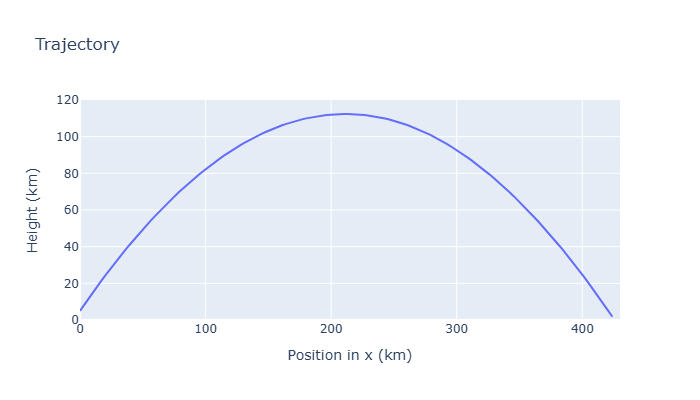

In [15]:
pio.renderers.default = "png"
fig = px.line(df_plot, x='Position in x (km)', y='Height (km)', range_x=[0, 430], range_y=[0, 120], title='Trajectory')

fig.update_layout(
    xaxis_title='Position in x (km)',
    yaxis_title='Height (km)',
    height=400,
    width=700
)

fig.show()

The plot can also be created with matplotlib:

An angle is defined to create the 2D approximation of the Earth:

In [16]:
theta = np.linspace(0, 2 * np.pi)

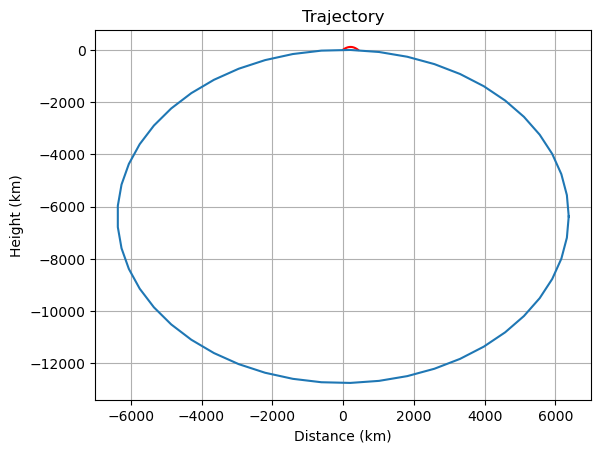

In [17]:
pio.renderers.default = "png"
# 2D approximation of the Earth
x = RE / 1000 * np.cos(theta)
y = RE / 1000 * np.sin(theta) - RE/1000

# Figure definition
fig0, ax = plt.subplots()
ax.plot(x_km, h_km, label='Trajectory', color='red')
ax.plot = ax.plot(x, y, label="Earth's surface")
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Height (km)')
ax.set_title('Trajectory')
plt.grid(True)
plt.show()

A plot showing the change in all variables over time is created:

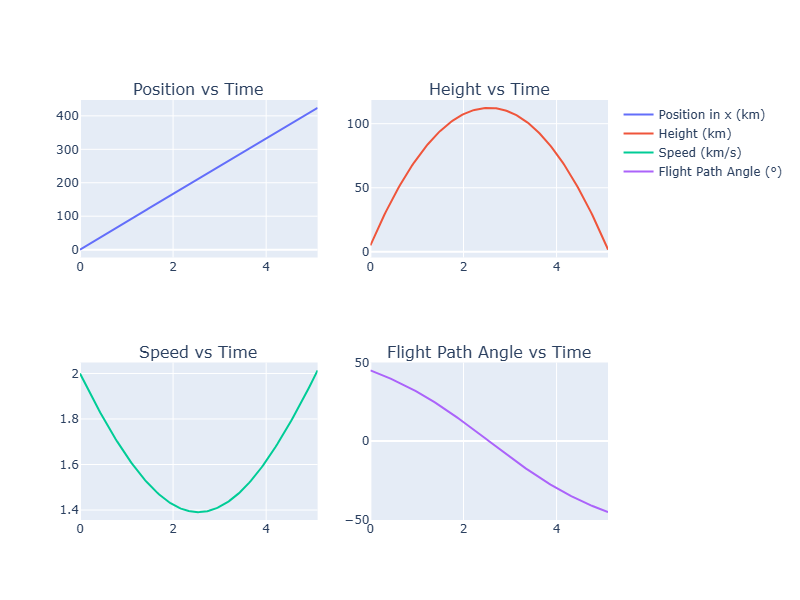

In [18]:
pio.renderers.default = "png"
fig1 = make_subplots(rows=2, cols=2,
                    subplot_titles=("Position vs Time", "Height vs Time", "Speed vs Time", "Flight Path Angle vs Time"))

fig1.add_trace(go.Scatter(x=df_plot['Time (min)'], y=df_plot['Position in x (km)'], name='Position in x (km)'), row=1, col=1)
fig1.add_trace(go.Scatter(x=df_plot['Time (min)'], y=df_plot['Height (km)'], name='Height (km)'), row=1, col=2)
fig1.add_trace(go.Scatter(x=df_plot['Time (min)'], y=df_plot['Speed (km/s)'], name='Speed (km/s)'), row=2, col=1)
fig1.add_trace(go.Scatter(x=df_plot['Time (min)'], y=df_plot['gamma (°)'], name='Flight Path Angle (°)'), row=2, col=2)

fig1.update_layout(
    height=600,
    width=800
)

fig1.show()

### 3D Plots

The values found in the $df_{plot}$ dataframe are used for convenience:

$$
x_{km} = df1['x']/1000
$$

$$
h_{km} = df1['h']/1000
$$

Some parameters are defined to create all the plots: the values on the $z$ axis for the rocket trajectory and the values needed to plot the sphere representing the Earth.

In [19]:
# Values on z
zs = np.zeros(len(x_km))

# Values for plotting the sphere
alpha, beta = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x = RE / 1000 * np.outer(np.cos(alpha), np.sin(beta))
y = RE / 1000 * np.outer(np.sin(alpha), np.sin(beta))
z = RE / 1000 * np.outer(np.ones(np.size(alpha)), np.cos(beta)) - RE/1000

Code containing a simplified shape of the Earth and the rocket trajectory is created.

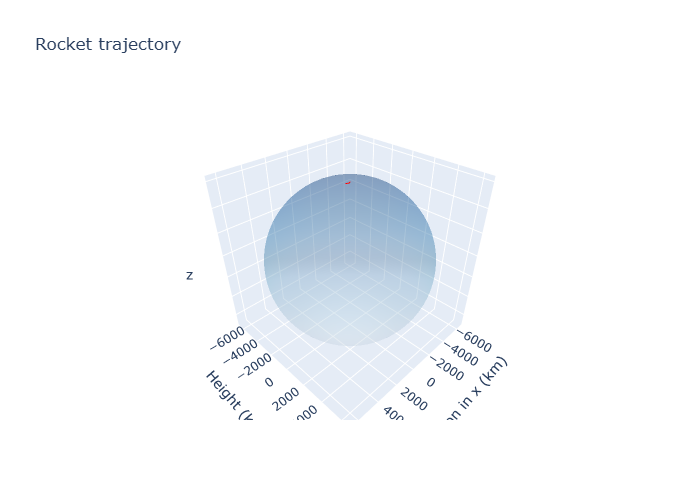

In [20]:
pio.renderers.default = "png"
fig3 = go.Figure()
fig3.add_trace(go.Scatter3d(x=x_km, y=h_km, z=zs, mode='lines', name='Trajectory', line=dict(color='red')))

fig3.add_trace(go.Surface(x=x, y=y, z=z, opacity=0.25, showscale=False, colorscale='Blues'))

fig3.update_layout(
    scene=dict(
        xaxis=dict(title='Position in x (km)'),
        yaxis=dict(title='Height (km)'),
        zaxis=dict(showticklabels=False)
    ),
    title_text='Rocket trajectory'
)

fig3.show()

An animation showing the rocket's trajectory as a point is created:

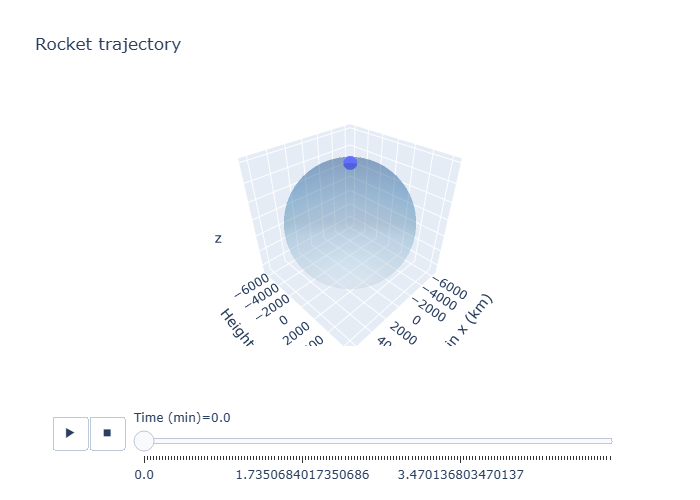

In [21]:
pio.renderers.default = "png"
fig2 = go.Figure()
fig2 = px.scatter_3d(df_plot, x='Position in x (km)', y='Height (km)', z=zs, animation_frame='Time (min)',
                     title='Rocket trajectory')

fig2.add_trace(go.Surface(x=x, y=y, z=z, opacity=0.25, showscale=False, colorscale='Blues'))

fig2.update_layout(
    scene=dict(
        xaxis=dict(title='Position in x (km)'),
        yaxis=dict(title='Height (km)'),
        zaxis=dict(showticklabels=False)
    )
)

fig2.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1
fig2.show()

This plot can also be created using matplotlib:

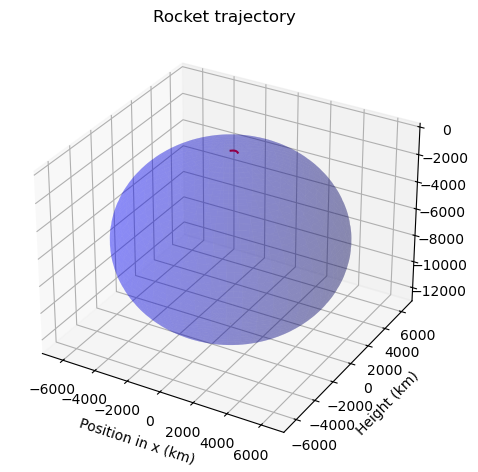

In [22]:
pio.renderers.default = "png"
fig4 = plt.figure()
ax = fig4.add_subplot(111, projection='3d')

ax.plot(x_km, h_km, zs, label='Trajectory', color='red')
ax.plot_surface(x, y, z, alpha=0.25, color='blue')

ax.set_xlabel('Position in x (km)')
ax.set_ylabel('Height (km)')
ax.set_zlabel('')
ax.set_title('Rocket trajectory')
fig4.tight_layout()
plt.show()

## References

- Complete list of symbols in LaTeX | Manualdelatex.com. (2025). Manualdelatex.com. https://manualdelatex.com/simbolos#chapter9

- Malvik Vaghadia. (2023, January 16). Create animated plots in Python with Plotly Express. Medium. https://medium.com/@malvik01/create-animated-plots-in-python-with-plotly-express-a12939f190b8

- plotlygraphs. (2019, July 3). Subplots. Plotly.com. https://plotly.com/python/subplots/

- PYTHON: How to plot a circle with matplotlib.pyplot? (2020, January 2). Stack Overflow en Español. https://es.stackoverflow.com/questions/319334/python-c%C3%B3mo-gráficar-un-circulo-con-matplotlib-pyplot

- Sakamoto, A. (2023, June 6). [Explained] Multiple Graphs in the Same Figure in Matplotlib. Kanaries.net. https://docs.kanaries.net/es/topics/Matplotlib/matplotlib-multiple-plots-on-same-figure